# Modelos supervisados

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

file_path = '/content/sample_data/MetroPT3(AirCompressor).csv'
df = pd.read_csv(file_path)
df = df.drop(columns=["Unnamed: 0"])

print(f"Successfully read '{file_path}'")


Successfully read '/content/sample_data/MetroPT3(AirCompressor).csv'


 ## CONSTRUCCIÓN DE LA VARIABLE OBJETIVO: failure


In [2]:


df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
df['failure'] = 0

fallas_conocidas = [
    # (descripción,                   inicio,                  fin)
    ('Air Leak #1',    '2020-04-18 00:00:00', '2020-04-18 23:59:00'),
    ('Air Leak #2',    '2020-05-29 23:30:00', '2020-05-30 06:00:00'),
    ('Air Leak #3',    '2020-06-05 10:00:00', '2020-06-07 14:30:00'),
    ('Air Leak #4',    '2020-07-15 14:30:00', '2020-07-15 19:00:00'),
]

for descripcion, inicio, fin in fallas_conocidas:
    mask = (df['timestamp'] >= inicio) & (df['timestamp'] <= fin)
    registros = mask.sum()
    df.loc[mask, 'failure'] = 1
    print(f" {descripcion}: {registros} registros marcados")

print(f"\nTotal registros de falla:     {df['failure'].sum()}")
print(f"Total registros normales:     {(df['failure'] == 0).sum()}")
print(f"Proporción de falla:          {df['failure'].mean():.4%}")

 Air Leak #1: 8657 registros marcados
 Air Leak #2: 2360 registros marcados
 Air Leak #3: 17315 registros marcados
 Air Leak #4: 1622 registros marcados

Total registros de falla:     29954
Total registros normales:     1486994
Proporción de falla:          1.9746%


Dado que el dataset no incluye etiquetas de falla, se construyó la variable objetivo failure a partir de los reportes de mantenimiento provistos por la empresa operadora, los cuales documentan 4 eventos de falla tipo Air Leak ocurridos entre abril y julio de 2020, con un total de 29,954 registros etiquetados como falla (1.97% del total)

El dataset presenta un marcado desbalance de clases, con un 98.03% de registros normales frente a un 1.97% de registros de falla, esto es muy compun en datasets de mantenimiento, dado que lo normal es que el tren este funcionando bien.

In [3]:
# 1. Definimos el horizonte de predicción (2 horas = 720 registros)
window_2h = 720

# 2. Marcamos el inicio de la pre-falla mirando 2 horas hacia el futuro
df['pre_failure'] = df['failure'].shift(-window_2h, fill_value=0)

# 3. Propagamos el valor hacia atrás para cubrir TODA la ventana de 2 horas
# Usamos rolling con el mismo tamaño de ventana
df['pre_failure'] = df['pre_failure'].rolling(window=window_2h, min_periods=1).max().astype(int)

# 4. Limpieza lógica crucial:
# Si ya estamos dentro del periodo de falla (failure=1),
# quitamos la etiqueta pre_failure para que el modelo no se confunda.
df.loc[df['failure'] == 1, 'pre_failure'] = 0

# 5. Verificamos el resultado
print(f"Registros de falla real: {df['failure'].sum()}")
print(f"Registros de ventana preventiva (2h antes): {df['pre_failure'].sum()}")

Registros de falla real: 29954
Registros de ventana preventiva (2h antes): 2880


In [4]:
df['pre_failure'].value_counts()

,count
pre_failure,
0,1514068
1,2880


Se realizó una validación visual del etiquetado temporal para verificar la ausencia de data leakage, confirmando que la ventana de pre-falla precede consistentemente a cada evento de falla sin solaparse con registros posteriores a la ocurrencia.

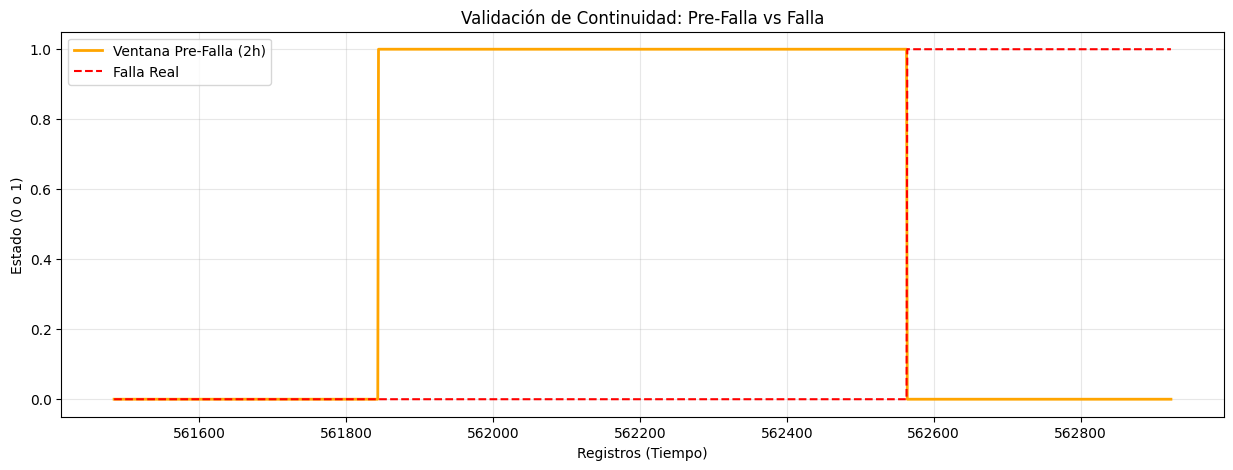

In [5]:

# Buscamos el índice de la primera falla para centrar el gráfico ahí
indice_falla = df[df['failure'] == 1].index[0]

# Tomamos un rango: 3 horas antes y 1 hora después de la falla
# 3h antes = 1080 registros | 1h después = 360 registros
start = max(0, indice_falla - 1080)
end = indice_falla + 360
df_slice = df.iloc[start:end]

plt.figure(figsize=(15, 5))
plt.plot(df_slice.index, df_slice['pre_failure'], label='Ventana Pre-Falla (2h)', color='orange', linewidth=2)
plt.plot(df_slice.index, df_slice['failure'], label='Falla Real', color='red', linestyle='--')

plt.title("Validación de Continuidad: Pre-Falla vs Falla")
plt.xlabel("Registros (Tiempo)")
plt.ylabel("Estado (0 o 1)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La validación visual del etiquetado temporal confirma la correcta construcción de la ventana de pre-falla: la señal preventiva antecede consistentemente al evento de falla real en aproximadamente 720 registros (2 horas), sin solapamiento entre ambas etiquetas, lo que garantiza la ausencia de data leakage en el proceso de entrenamiento.


# **Análisis de correlaciones**

---




Se analizará la correlación entre las variables de sensores y la etiqueta pre_failure como paso previo a la selección de características, identificando los sensores con mayor capacidad discriminativa para la predicción de fallos.

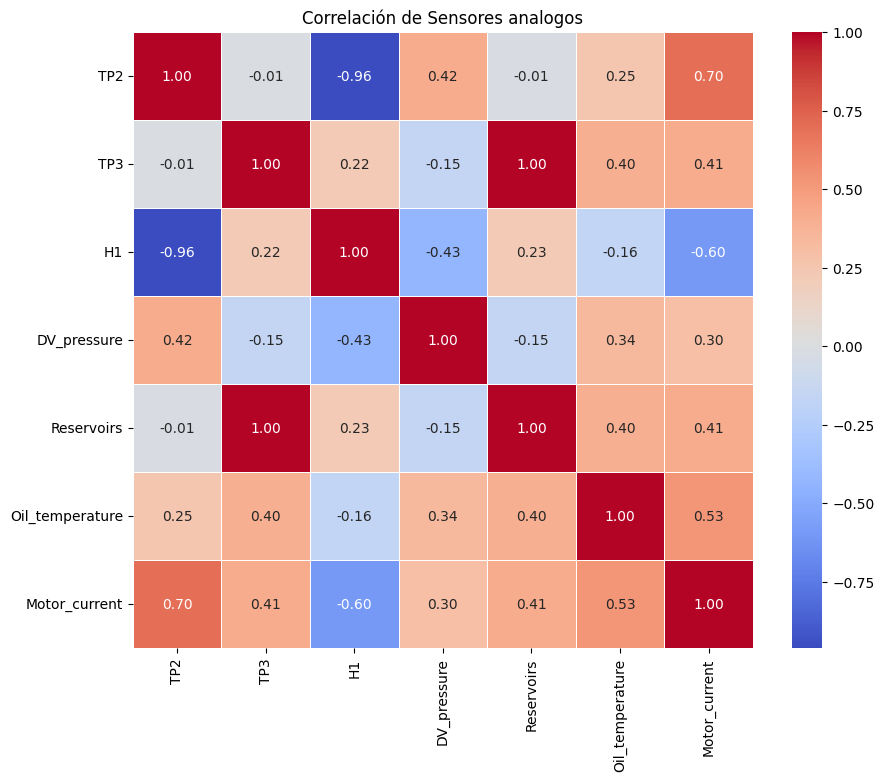

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Aseguramos que las etiquetas sean numéricas para la correlación
df['failure'] = df['failure'].astype(int)
df['pre_failure'] = df['pre_failure'].astype(int)

# 2. Seleccionamos las columnas de sensores + nuestras nuevas etiquetas
analogicas = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
              'Oil_temperature', 'Motor_current']

corr_matrix = df[analogicas].corr()

# 3. Graficamos
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlación de Sensores analogos')
plt.show()

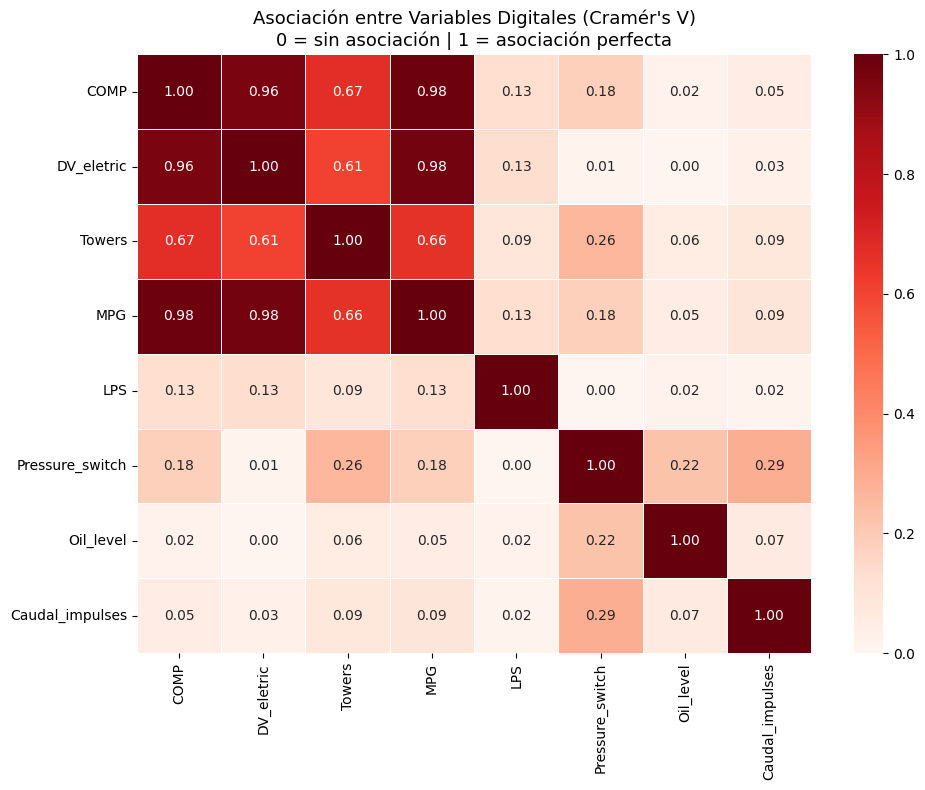

In [7]:

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calcula Cramér's V entre dos variables categóricas."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix, correction=False)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - (r-1)**2/(n-1)
    k_corr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2_corr / min((k_corr-1), (r_corr-1)))

# Variables digitales identificadas en el dataset
digitales = ['COMP', 'DV_eletric', 'Towers', 'MPG',
             'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

# Construimos la matriz de Cramér's V manualmente
n = len(digitales)
matriz_cramer = pd.DataFrame(np.zeros((n, n)),
                              index=digitales,
                              columns=digitales)

for col1 in digitales:
    for col2 in digitales:
        if col1 == col2:
            matriz_cramer.loc[col1, col2] = 1.0
        else:
            matriz_cramer.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Graficamos
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_cramer, annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, vmin=0, vmax=1)
plt.title("Asociación entre Variables Digitales (Cramér's V)\n"
          "0 = sin asociación | 1 = asociación perfecta", fontsize=13)
plt.tight_layout()
plt.show()

## Eliminación de variables redundantes
---
**Basado en el análisis de correlación, se encontraron estas redundancias :**
* TP2 y H1
* TP3 y Reservoirs
* COMP, MPG, DV_electric

---
para definir cual variable eliminar se analizará la varianza explicada por cada variable

In [8]:
grupos = {
    'TP2 vs H1': ['TP2', 'H1'],
    'TP3 vs Reservoirs': ['TP3', 'Reservoirs'],
    'COMP vs DV_eletric vs MPG': ['COMP', 'DV_eletric', 'MPG']
}

for grupo, variables in grupos.items():
    print(f"\n=== {grupo} ===")
    for v in variables:
        print(f"  {v}: std = {df[v].std():.4f} | var = {df[v].var():.4f}")


=== TP2 vs H1 ===
  TP2: std = 3.2509 | var = 10.5685
  H1: std = 3.3332 | var = 11.1102

=== TP3 vs Reservoirs ===
  TP3: std = 0.6391 | var = 0.4084
  Reservoirs: std = 0.6383 | var = 0.4074

=== COMP vs DV_eletric vs MPG ===
  COMP: std = 0.3694 | var = 0.1365
  DV_eletric: std = 0.3672 | var = 0.1348
  MPG: std = 0.3733 | var = 0.1393


 H1 mayor varianza que TP2, TP3 mayor que Reservoirs, y MPG mayor que COMP y DV_eletric. Se conservan las variables H1, TP3 y MPG

In [9]:
cols_eliminar = ['TP2', 'Reservoirs', 'COMP', 'DV_eletric']
df = df.drop(columns=cols_eliminar)

print(f"Variables eliminadas: {cols_eliminar}")
print(f"\nVariables restantes ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\nShape del dataset: {df.shape}")

Variables eliminadas: ['TP2', 'Reservoirs', 'COMP', 'DV_eletric']

Variables restantes (14):
['timestamp', 'TP3', 'H1', 'DV_pressure', 'Oil_temperature', 'Motor_current', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses', 'failure', 'pre_failure']

Shape del dataset: (1516948, 14)


## Análisis de Correlaciones para irrelevancia con la Variable Objetivo
---

Se eliminan variables con correlación muy baja con la variable
objetivo (correlación menor a 0,05).

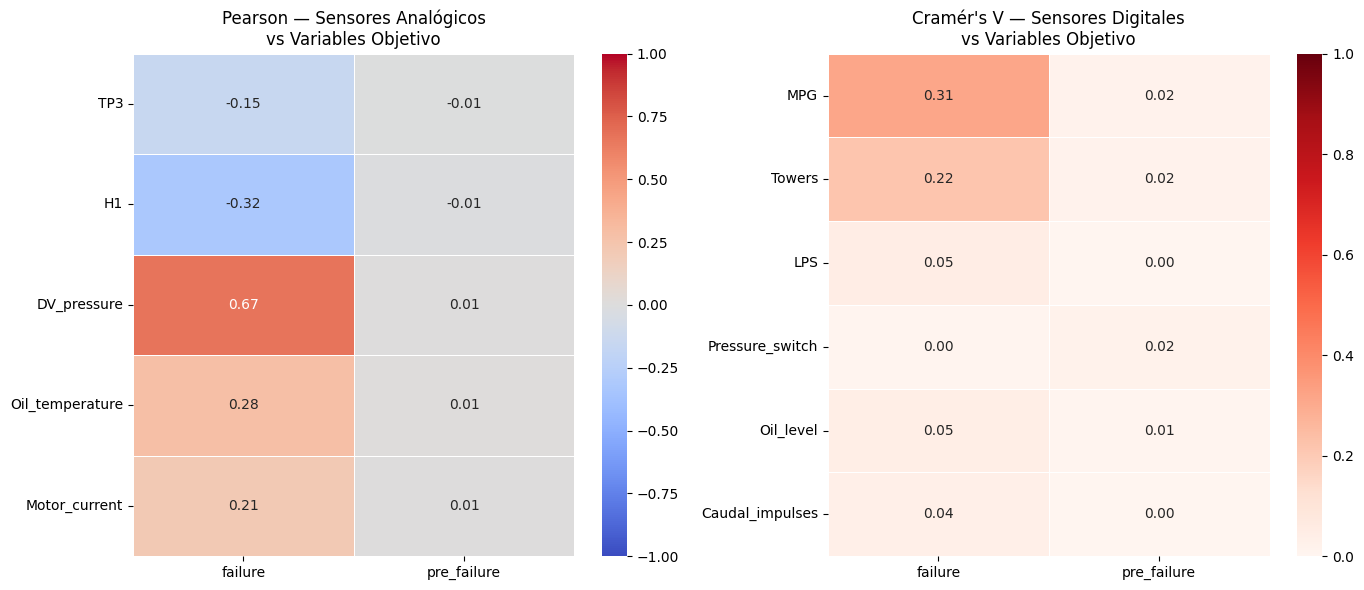

In [10]:


from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix, correction=False)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - (r-1)**2/(n-1)
    k_corr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2_corr / min((k_corr-1), (r_corr-1)))

analogicas  = ['TP3', 'H1', 'DV_pressure', 'Oil_temperature', 'Motor_current']
digitales   = ['MPG', 'Towers', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']
targets     = ['failure', 'pre_failure']

# --- Pearson: analógicas vs targets ---
corr_pearson = df[analogicas + targets].corr()[targets].drop(targets)

# --- Cramér's V: digitales vs targets ---
cramer_data = {}
for t in targets:
    cramer_data[t] = [cramers_v(df[d], df[t]) for d in digitales]

corr_cramer = pd.DataFrame(cramer_data, index=digitales)

# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Pearson — Sensores Analógicos\nvs Variables Objetivo', fontsize=12)

sns.heatmap(corr_cramer, annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Cramér's V — Sensores Digitales\nvs Variables Objetivo", fontsize=12)

plt.tight_layout()
plt.show()

La ausencia de correlación lineal entre los sensores y la variable pre_failure no indica que los sensores carezcan de capacidad predictiva, sino que dicha capacidad es de naturaleza temporal y no se captura mediante métricas estáticas. Los patrones relevantes para la predicción se manifiestan como tendencias y cambios de variabilidad en el tiempo, no como valores puntuales elevados, lo que justifica el uso de ingeniería de características basada en ventanas deslizantes en los modelos posteriores.





## ELIMINACIÓN DE VARIABLES POR BAJA CORRELACIÓN CON FAILURE
---
**Variables con correlación con failure < 0.05**

* Pressure_switch: Cramér's V = 0.00 con failure
* LPS:Cramér's V = 0.05 con failure
* Oil_level:Cramér's V = 0.05 con failure
* Caudal_impulses: Cramér's V = 0.04 con failure

In [11]:
cols_baja_correlacion = ['Pressure_switch', 'LPS', 'Oil_level', 'Caudal_impulses']
df = df.drop(columns=cols_baja_correlacion)

print(f"Variables eliminadas: {cols_baja_correlacion}")
print(f"\nVariables finales del dataset ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\nShape final: {df.shape}")

Variables eliminadas: ['Pressure_switch', 'LPS', 'Oil_level', 'Caudal_impulses']

Variables finales del dataset (10):
['timestamp', 'TP3', 'H1', 'DV_pressure', 'Oil_temperature', 'Motor_current', 'Towers', 'MPG', 'failure', 'pre_failure']

Shape final: (1516948, 10)


## Entrenamiento

---
Cada modelo se entrenará con las dos variables objetivos del dataset: failure y pre_failure, la primera para ver si el modelo puede predecir que una falla está ocurriendo y con pre_failure como variable objetivo se va a responder si el modelo se puede anticipar a una falla antes de que esta ocurra

In [19]:
# ============================================================
# CONFIGURACIÓN LEAVE-ONE-FAULT-OUT (LOFO)
# Con solo 4 eventos de falla, LOFO garantiza que cada fold
# evalúa sobre una falla completa que el modelo nunca vio,
# evitando el sesgo de la división temporal 70/30 donde
# todas las fallas quedaban en entrenamiento.
#
# Cada fold incluye:
# - Test: ventana de falla + ventana pre-falla del evento excluido
#   más datos normales en proporción 1:5
# - Train: todos los demás datos con under-sampling 1:5
# ============================================================

import pandas as pd
import numpy as np

# Definición de los 4 eventos de falla con sus ventanas de pre-falla
fallas_lofo = [
    {
        'nombre': 'Air Leak #1',
        'failure_inicio':    pd.Timestamp('2020-04-18 00:00:00'),
        'failure_fin':       pd.Timestamp('2020-04-18 23:59:00'),
        'prefailure_inicio': pd.Timestamp('2020-04-17 22:00:00'),  # 2h antes
        'prefailure_fin':    pd.Timestamp('2020-04-17 23:59:50'),  # justo antes de failure
    },
    {
        'nombre': 'Air Leak #2',
        'failure_inicio':    pd.Timestamp('2020-05-29 23:30:00'),
        'failure_fin':       pd.Timestamp('2020-05-30 06:00:00'),
        'prefailure_inicio': pd.Timestamp('2020-05-29 21:30:00'),
        'prefailure_fin':    pd.Timestamp('2020-05-29 23:29:50'),
    },
    {
        'nombre': 'Air Leak #3',
        'failure_inicio':    pd.Timestamp('2020-06-05 10:00:00'),
        'failure_fin':       pd.Timestamp('2020-06-07 14:30:00'),
        'prefailure_inicio': pd.Timestamp('2020-06-05 08:00:00'),
        'prefailure_fin':    pd.Timestamp('2020-06-05 09:59:50'),
    },
    {
        'nombre': 'Air Leak #4',
        'failure_inicio':    pd.Timestamp('2020-07-15 14:30:00'),
        'failure_fin':       pd.Timestamp('2020-07-15 19:00:00'),
        'prefailure_inicio': pd.Timestamp('2020-07-15 12:30:00'),
        'prefailure_fin':    pd.Timestamp('2020-07-15 14:29:50'),
    },
]

def crear_folds_lofo(df, target, ratio=5):
    """
    Genera los 4 folds LOFO con under-sampling 1:ratio.

    Para cada fold:
    - Test: registros de falla/pre-falla del evento excluido
            + normales aleatorios en proporción 1:ratio
    - Train: todos los demás registros
             + under-sampling de normales en proporción 1:ratio

    Parámetros:
        df     : DataFrame con todas las variables
        target : 'failure' o 'pre_failure'
        ratio  : proporción negativos/positivos (default 5)

    Retorna lista de tuplas (X_train, X_test, y_train, y_test, nombre)
    """
    sensores = ['TP3', 'H1', 'DV_pressure', 'Oil_temperature',
                'Motor_current', 'MPG', 'Towers']
    folds = []

    for falla in fallas_lofo:
        # --- Definir máscara del evento excluido ---
        if target == 'failure':
            mascara_evento = (
                (df['timestamp'] >= falla['failure_inicio']) &
                (df['timestamp'] <= falla['failure_fin'])
            )
        else:  # pre_failure
            mascara_evento = (
                (df['timestamp'] >= falla['prefailure_inicio']) &
                (df['timestamp'] <= falla['prefailure_fin'])
            )

        # --- Construir TEST ---
        test_pos  = df[mascara_evento]
        test_neg  = df[~mascara_evento & (df[target] == 0)].sample(
            n=min(len(test_pos) * ratio,
                  len(df[~mascara_evento & (df[target] == 0)])),
            random_state=42
        )
        test_df = pd.concat([test_pos, test_neg]).sort_index()

        # --- Construir TRAIN ---
        # Excluimos todo el evento (failure + pre-falla) del fold actual
        mascara_exclusion = (
            (df['timestamp'] >= falla['prefailure_inicio']) &
            (df['timestamp'] <= falla['failure_fin'])
        )
        train_df_full = df[~mascara_exclusion]
        train_pos = train_df_full[train_df_full[target] == 1]
        train_neg = train_df_full[train_df_full[target] == 0].sample(
            n=min(len(train_pos) * ratio,
                  len(train_df_full[train_df_full[target] == 0])),
            random_state=42
        )
        train_df = pd.concat([train_pos, train_neg]).sort_index()

        X_train = train_df[sensores]
        y_train = train_df[target]
        X_test  = test_df[sensores]
        y_test  = test_df[target]

        folds.append((X_train, X_test, y_train, y_test, falla['nombre']))

        print(f"Fold {falla['nombre']}:")
        print(f"  Train → positivos: {y_train.sum()} | negativos: {(y_train==0).sum()}")
        print(f"  Test  → positivos: {y_test.sum()}  | negativos: {(y_test==0).sum()}")
        print()

    return folds

# Verificación
print("=== FOLDS CON TARGET: failure ===")
folds_failure = crear_folds_lofo(df, target='failure')

print("=== FOLDS CON TARGET: pre_failure ===")
folds_prefailure = crear_folds_lofo(df, target='pre_failure')

=== FOLDS CON TARGET: failure ===
Fold Air Leak #1:
  Train → positivos: 21297 | negativos: 106485
  Test  → positivos: 8657  | negativos: 43285

Fold Air Leak #2:
  Train → positivos: 27594 | negativos: 137970
  Test  → positivos: 2360  | negativos: 11800

Fold Air Leak #3:
  Train → positivos: 12639 | negativos: 63195
  Test  → positivos: 17315  | negativos: 86575

Fold Air Leak #4:
  Train → positivos: 28332 | negativos: 141660
  Test  → positivos: 1622  | negativos: 8110

=== FOLDS CON TARGET: pre_failure ===
Fold Air Leak #1:
  Train → positivos: 2283 | negativos: 11415
  Test  → positivos: 597  | negativos: 2985

Fold Air Leak #2:
  Train → positivos: 2160 | negativos: 10800
  Test  → positivos: 719  | negativos: 3637

Fold Air Leak #3:
  Train → positivos: 2160 | negativos: 10800
  Test  → positivos: 719  | negativos: 3631

Fold Air Leak #4:
  Train → positivos: 2160 | negativos: 10800
  Test  → positivos: 719  | negativos: 3631



# Regresión Logística: failure

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, recall_score, precision_score
import numpy as np

def entrenar_lofo(nombre_modelo, pipeline, folds, target_nombre):
    """
    Entrena y evalúa un modelo con Leave-One-Fault-Out.
    Retorna métricas promedio ± desviación estándar sobre los 4 folds.
    """
    print(f"\n{'='*55}")
    print(f"{nombre_modelo} — target: {target_nombre}")
    print(f"{'='*55}")

    precisiones, recalls, f1s = [], [], []

    for X_train, X_test, y_train, y_test, nombre_falla in folds:
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        p  = precision_score(y_test, y_pred, zero_division=0)
        r  = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        precisiones.append(p)
        recalls.append(r)
        f1s.append(f1)

        print(f"\n  Fold {nombre_falla}:")
        print(f"    Precision: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f}")

    print(f"\n  {'─'*45}")
    print(f"  PROMEDIO LOFO:")
    print(f"    Precision: {np.mean(precisiones):.3f} ± {np.std(precisiones):.3f}")
    print(f"    Recall:    {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
    print(f"    F1-Score:  {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

    return {
        'modelo':          nombre_modelo,
        'target':          target_nombre,
        'precision_mean':  np.mean(precisiones),
        'precision_std':   np.std(precisiones),
        'recall_mean':     np.mean(recalls),
        'recall_std':      np.std(recalls),
        'f1_mean':         np.mean(f1s),
        'f1_std':          np.std(f1s),
    }

# Guardamos resultados de todos los modelos aquí
# Esta lista se reutiliza en todas las celdas siguientes
resultados = []

pipeline_lr_failure = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

res_lr_failure = entrenar_lofo(
    'Regresión Logística',
    pipeline_lr_failure,
    folds_failure,
    'failure'
)
resultados.append(res_lr_failure)


Regresión Logística — target: failure

  Fold Air Leak #1:
    Precision: 0.926 | Recall: 0.855 | F1: 0.889

  Fold Air Leak #2:
    Precision: 0.902 | Recall: 0.986 | F1: 0.942

  Fold Air Leak #3:
    Precision: 0.889 | Recall: 0.998 | F1: 0.941

  Fold Air Leak #4:
    Precision: 0.058 | Recall: 0.005 | F1: 0.009

  ─────────────────────────────────────────────
  PROMEDIO LOFO:
    Precision: 0.694 ± 0.367
    Recall:    0.711 ± 0.411
    F1-Score:  0.695 ± 0.397


# Regresión Logística: pre_failure

In [21]:
pipeline_lr_prefailure = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

res_lr_prefailure = entrenar_lofo(
    'Regresión Logística',
    pipeline_lr_prefailure,
    folds_prefailure,
    'pre_failure'
)
resultados.append(res_lr_prefailure)


Regresión Logística — target: pre_failure

  Fold Air Leak #1:
    Precision: 0.000 | Recall: 0.000 | F1: 0.000

  Fold Air Leak #2:
    Precision: 0.172 | Recall: 0.344 | F1: 0.229

  Fold Air Leak #3:
    Precision: 0.175 | Recall: 0.356 | F1: 0.235

  Fold Air Leak #4:
    Precision: 0.001 | Recall: 0.003 | F1: 0.002

  ─────────────────────────────────────────────
  PROMEDIO LOFO:
    Precision: 0.087 ± 0.086
    Recall:    0.176 ± 0.174
    F1-Score:  0.116 ± 0.116


El ± indica la desviación estándar de la métrica a través de los 4 folds LOFO.


El modelo baseline de Regresión Logística mostró resultados opuestos según la variable objetivo. Para detección de falla activa (failure), el recall promedio fue de 0.711 ± 0.411 y el F1 de 0.695 ± 0.397, con tres fallas detectadas con alta efectividad pero un colapso total en la falla #4 (Recall: 0.005), lo que expone una incapacidad del modelo lineal para generalizar a eventos de falla con patrones distintos a los vistos en entrenamiento. Para anticipación de falla (pre_failure), el recall promedio fue de apenas 0.176 ± 0.174, confirmando que las señales previas a la falla no son linealmente separables en los valores instantáneos de los sensores. La alta variabilidad entre folds en ambos casos motiva el uso de modelos no lineales e ingeniería de características temporales en los modelos siguientes.

## Random Forest: failure

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, precision_score
import numpy as np

modelo_rf_failure = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

res_rf_failure = entrenar_lofo(
    'Random Forest',
    modelo_rf_failure,
    folds_failure,
    'failure'
)
resultados.append(res_rf_failure)


Random Forest — target: failure

  Fold Air Leak #1:
    Precision: 0.469 | Recall: 0.008 | F1: 0.015

  Fold Air Leak #2:
    Precision: 0.958 | Recall: 0.985 | F1: 0.971

  Fold Air Leak #3:
    Precision: 0.882 | Recall: 0.155 | F1: 0.263

  Fold Air Leak #4:
    Precision: 0.000 | Recall: 0.000 | F1: 0.000

  ─────────────────────────────────────────────
  PROMEDIO LOFO:
    Precision: 0.577 ± 0.382
    Recall:    0.287 ± 0.408
    F1-Score:  0.312 ± 0.395


## Random Forest: prefailure

In [23]:
modelo_rf_prefailure = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

res_rf_prefailure = entrenar_lofo(
    'Random Forest',
    modelo_rf_prefailure,
    folds_prefailure,
    'pre_failure'
)
resultados.append(res_rf_prefailure)


Random Forest — target: pre_failure

  Fold Air Leak #1:
    Precision: 0.621 | Recall: 1.000 | F1: 0.766

  Fold Air Leak #2:
    Precision: 0.560 | Recall: 0.409 | F1: 0.473

  Fold Air Leak #3:
    Precision: 0.586 | Recall: 0.338 | F1: 0.429

  Fold Air Leak #4:
    Precision: 0.000 | Recall: 0.000 | F1: 0.000

  ─────────────────────────────────────────────
  PROMEDIO LOFO:
    Precision: 0.442 ± 0.256
    Recall:    0.437 ± 0.360
    F1-Score:  0.417 ± 0.273


Los resultados del Random Forest muestran un patrón mixto respecto al baseline. Para detección de falla activa (failure), el recall promedio cayó a 0.287 ± 0.408 — peor que la Regresión Logística (0.711) — con un comportamiento extremadamente inconsistente: la falla #2 fue detectada casi perfectamente (Recall: 0.985) mientras que las fallas #1, #3 y #4 tuvieron recall cercano a cero. Para anticipación de falla (pre_failure), el Random Forest sí superó al baseline con un recall promedio de 0.437 ± 0.360 y F1 de 0.417 ± 0.273, destacando el fold 1 con recall perfecto (1.000). Sin embargo, la falla #4 sigue siendo un punto ciego para ambos targets y ambos modelos, lo que refuerza la hipótesis de que este evento tiene una dinámica diferente a las demás fallas. La alta desviación estándar en todos los casos advierte que ningún modelo ha logrado generalizar consistentemente a todos los eventos.

## ¿Qué está pasando con la última falla?
---
Este gráfico muestra cada sensor (filas) durante cada falla (columnas), con la zona naranja marcando las 2 horas de pre-falla y la zona roja la falla activa.

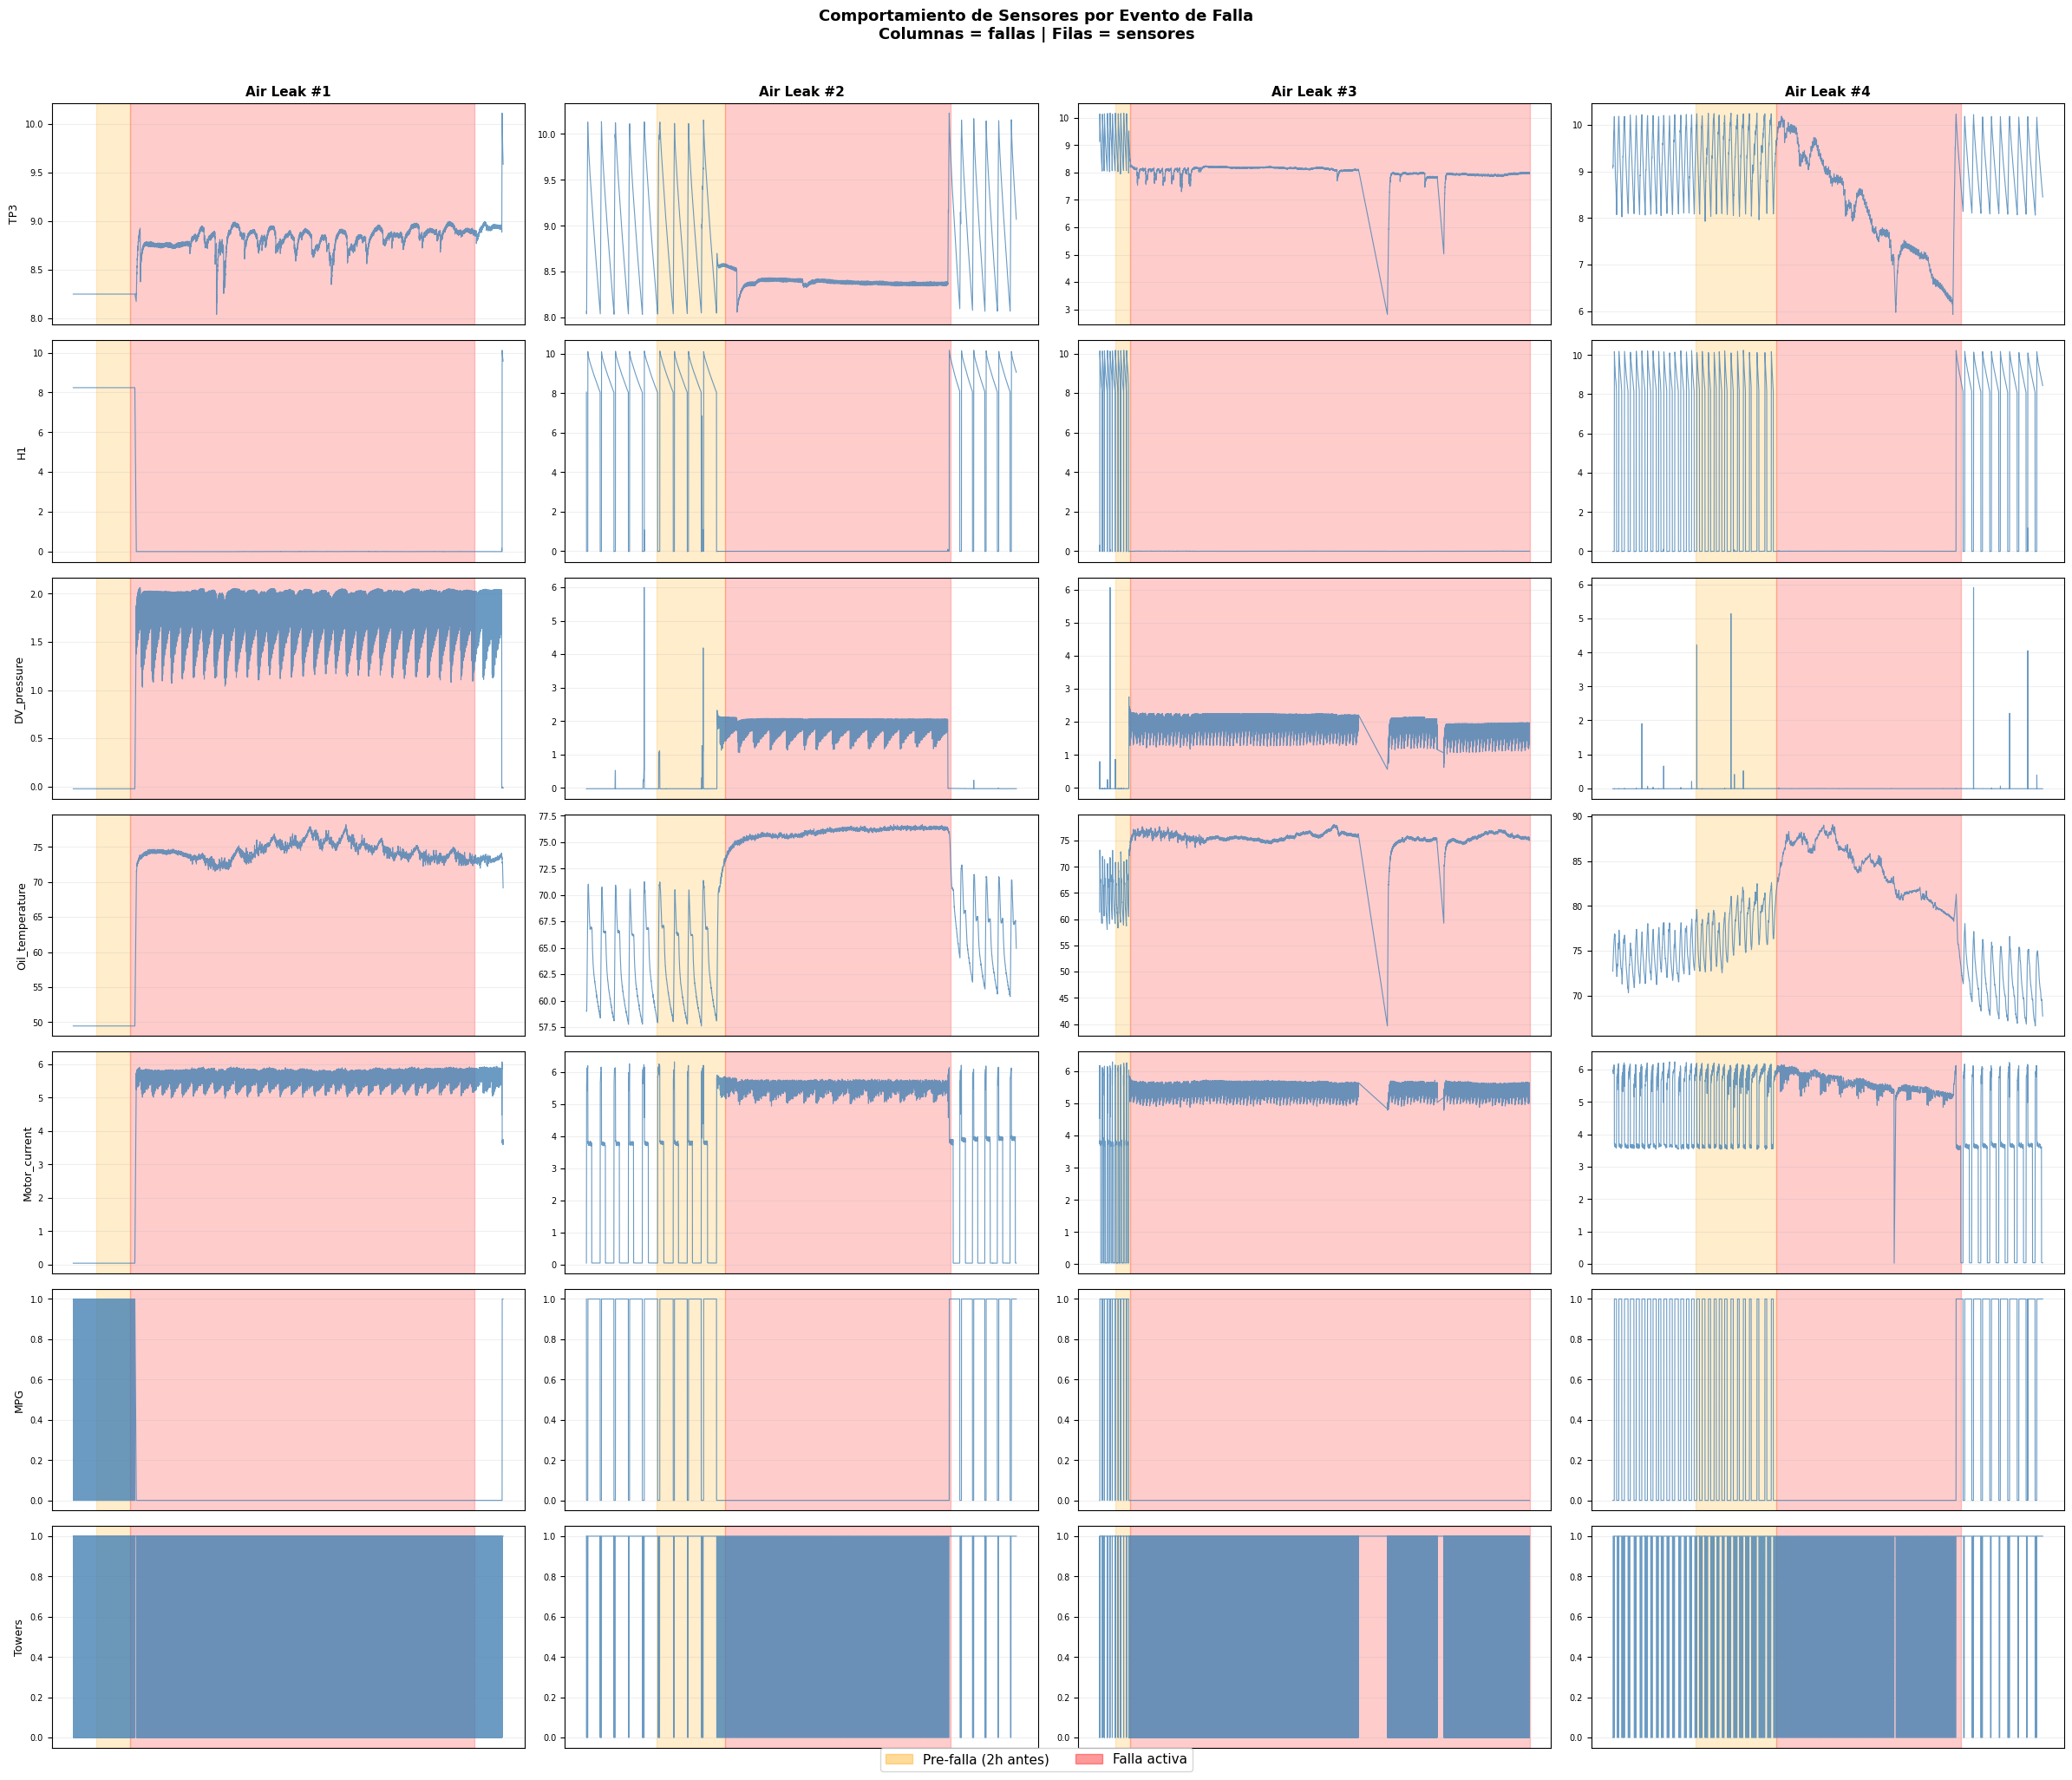

In [24]:
sensores_plot = ['TP3', 'H1', 'DV_pressure', 'Oil_temperature',
                 'Motor_current', 'MPG', 'Towers']

fallas_viz = [
    ('Air Leak #1', '2020-04-17 20:00:00', '2020-04-19 02:00:00'),
    ('Air Leak #2', '2020-05-29 19:30:00', '2020-05-30 08:00:00'),
    ('Air Leak #3', '2020-06-05 06:00:00', '2020-06-07 16:30:00'),
    ('Air Leak #4', '2020-07-15 10:30:00', '2020-07-15 21:00:00'),
]

fig, axes = plt.subplots(len(sensores_plot), len(fallas_viz),
                          figsize=(24, 20))

for col, (nombre, inicio, fin) in enumerate(fallas_viz):
    df_slice = df[
        (df['timestamp'] >= inicio) &
        (df['timestamp'] <= fin)
    ].copy()

    # Marcamos las zonas de pre-falla y falla
    for row, sensor in enumerate(sensores_plot):
        ax = axes[row, col]

        ax.plot(df_slice['timestamp'], df_slice[sensor],
                color='steelblue', linewidth=0.8, alpha=0.8)

        # Zona pre-falla en naranja
        ax.axvspan(
            df_slice[df_slice['pre_failure'] == 1]['timestamp'].min(),
            df_slice[df_slice['pre_failure'] == 1]['timestamp'].max(),
            alpha=0.2, color='orange', label='Pre-falla'
        )

        # Zona falla en rojo
        ax.axvspan(
            df_slice[df_slice['failure'] == 1]['timestamp'].min(),
            df_slice[df_slice['failure'] == 1]['timestamp'].max(),
            alpha=0.2, color='red', label='Falla'
        )

        # Títulos y etiquetas
        if row == 0:
            ax.set_title(nombre, fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(sensor, fontsize=9)

        ax.set_xticks([])
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(alpha=0.2)

# Leyenda global
handles = [
    plt.Rectangle((0,0),1,1, color='orange', alpha=0.4, label='Pre-falla (2h antes)'),
    plt.Rectangle((0,0),1,1, color='red',    alpha=0.4, label='Falla activa'),
]
fig.legend(handles=handles, loc='lower center', ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, -0.01))

plt.suptitle('Comportamiento de Sensores por Evento de Falla\n'
             'Columnas = fallas | Filas = sensores',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Vemos que en muchas de las fallas una ventana de 2 horas puede ser muy poca para que los modelos puedan aprender algún patrón, especialmente con la falla 4 no hay ningún indicio de que una falla vaya a ocurrir, se va a entrenar el XGBoost con este mismo umbral de 2 horas, pero en caso de que no tenga un buen desempeño se propone disminuir esa ventana a solo 1 hora

## XGBoost: failure

In [25]:
from xgboost import XGBClassifier
# --- 1. INGENIERÍA DE VARIABLES TEMPORALES ---
sensores_analogicos = ['TP3', 'H1', 'DV_pressure',
                       'Oil_temperature', 'Motor_current']

df_eng = df.copy()
for s in sensores_analogicos:
    df_eng[f'{s}_mean_30m'] = df_eng[s].rolling(window=180).mean()
    df_eng[f'{s}_std_30m']  = df_eng[s].rolling(window=180).std()

df_eng = df_eng.dropna().copy()
print(f"Registros tras ventana temporal: {len(df_eng)}")

# --- 2. FEATURES PARA XGBOOST ---
# Sensores originales + variables de ventana temporal
features_xgb = (sensores_analogicos +
                ['MPG', 'Towers'] +
                [c for c in df_eng.columns if '30m' in c])

# --- 3. FOLDS LOFO PARA XGBOOST ---
# Reconstruimos los folds usando df_eng en lugar de df
def crear_folds_lofo_eng(df_eng, target, ratio=5):
    folds = []
    for falla in fallas_lofo:
        if target == 'failure':
            mascara_evento = (
                (df_eng['timestamp'] >= falla['failure_inicio']) &
                (df_eng['timestamp'] <= falla['failure_fin'])
            )
        else:
            mascara_evento = (
                (df_eng['timestamp'] >= falla['prefailure_inicio']) &
                (df_eng['timestamp'] <= falla['prefailure_fin'])
            )

        mascara_exclusion = (
            (df_eng['timestamp'] >= falla['prefailure_inicio']) &
            (df_eng['timestamp'] <= falla['failure_fin'])
        )

        # Test
        test_pos = df_eng[mascara_evento]
        test_neg = df_eng[~mascara_evento & (df_eng[target] == 0)].sample(
            n=min(len(test_pos) * ratio,
                  len(df_eng[~mascara_evento & (df_eng[target] == 0)])),
            random_state=42
        )
        test_df = pd.concat([test_pos, test_neg]).sort_index()

        # Train
        train_df_full = df_eng[~mascara_exclusion]
        train_pos = train_df_full[train_df_full[target] == 1]
        train_neg = train_df_full[train_df_full[target] == 0].sample(
            n=min(len(train_pos) * ratio,
                  len(train_df_full[train_df_full[target] == 0])),
            random_state=42
        )
        train_df = pd.concat([train_pos, train_neg]).sort_index()

        X_train = train_df[features_xgb]
        y_train = train_df[target]
        X_test  = test_df[features_xgb]
        y_test  = test_df[target]

        folds.append((X_train, X_test, y_train, y_test, falla['nombre']))

        print(f"Fold {falla['nombre']}:")
        print(f"  Train → positivos: {y_train.sum()} | negativos: {(y_train==0).sum()}")
        print(f"  Test  → positivos: {y_test.sum()}  | negativos: {(y_test==0).sum()}")

    return folds

print("\n=== FOLDS XGB — TARGET: failure ===")
folds_xgb_failure = crear_folds_lofo_eng(df_eng, target='failure')

# --- 4. ENTRENAMIENTO ---
modelo_xgb_failure = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42
)

res_xgb_failure = entrenar_lofo(
    'XGBoost',
    modelo_xgb_failure,
    folds_xgb_failure,
    'failure'
)
resultados.append(res_xgb_failure)

Registros tras ventana temporal: 1516769

=== FOLDS XGB — TARGET: failure ===
Fold Air Leak #1:
  Train → positivos: 21297 | negativos: 106485
  Test  → positivos: 8657  | negativos: 43285
Fold Air Leak #2:
  Train → positivos: 27594 | negativos: 137970
  Test  → positivos: 2360  | negativos: 11800
Fold Air Leak #3:
  Train → positivos: 12639 | negativos: 63195
  Test  → positivos: 17315  | negativos: 86575
Fold Air Leak #4:
  Train → positivos: 28332 | negativos: 141660
  Test  → positivos: 1622  | negativos: 8110

XGBoost — target: failure

  Fold Air Leak #1:
    Precision: 0.990 | Recall: 0.012 | F1: 0.024

  Fold Air Leak #2:
    Precision: 1.000 | Recall: 0.992 | F1: 0.996

  Fold Air Leak #3:
    Precision: 0.959 | Recall: 0.007 | F1: 0.013

  Fold Air Leak #4:
    Precision: 0.000 | Recall: 0.000 | F1: 0.000

  ─────────────────────────────────────────────
  PROMEDIO LOFO:
    Precision: 0.737 ± 0.426
    Recall:    0.253 ± 0.427
    F1-Score:  0.258 ± 0.426


## XGBoost: pre_failure

In [26]:
print("=== FOLDS XGB — TARGET: pre_failure ===")
folds_xgb_prefailure = crear_folds_lofo_eng(df_eng, target='pre_failure')

modelo_xgb_prefailure = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42
)

res_xgb_prefailure = entrenar_lofo(
    'XGBoost',
    modelo_xgb_prefailure,
    folds_xgb_prefailure,
    'pre_failure'
)
resultados.append(res_xgb_prefailure)

=== FOLDS XGB — TARGET: pre_failure ===
Fold Air Leak #1:
  Train → positivos: 2283 | negativos: 11415
  Test  → positivos: 597  | negativos: 2985
Fold Air Leak #2:
  Train → positivos: 2160 | negativos: 10800
  Test  → positivos: 719  | negativos: 3637
Fold Air Leak #3:
  Train → positivos: 2160 | negativos: 10800
  Test  → positivos: 719  | negativos: 3631
Fold Air Leak #4:
  Train → positivos: 2160 | negativos: 10800
  Test  → positivos: 719  | negativos: 3631

XGBoost — target: pre_failure

  Fold Air Leak #1:
    Precision: 0.972 | Recall: 1.000 | F1: 0.986

  Fold Air Leak #2:
    Precision: 0.810 | Recall: 0.095 | F1: 0.169

  Fold Air Leak #3:
    Precision: 0.568 | Recall: 0.029 | F1: 0.056

  Fold Air Leak #4:
    Precision: 0.000 | Recall: 0.000 | F1: 0.000

  ─────────────────────────────────────────────
  PROMEDIO LOFO:
    Precision: 0.587 ± 0.368
    Recall:    0.281 ± 0.417
    F1-Score:  0.303 ± 0.399


XGBoost mostró el mismo patrón estructural que los modelos anteriores: excelente rendimiento en algunos folds y colapso total en otros, con la falla #4 siendo un punto ciego consistente en todos los casos. Para detección de falla activa (failure), el fold 2 alcanzó un recall casi perfecto de 0.992, pero los folds 1 y 3 cayeron a recall de 0.012 y 0.007 respectivamente, resultando en un promedio de apenas 0.253 ± 0.427 — peor que la Regresión Logística. Para anticipación de falla (pre_failure), el fold 1 logró recall perfecto de 1.000 con precisión de 0.972, pero los folds 2, 3 y 4 fallaron casi completamente, con recall promedio de 0.281 ± 0.417. El patrón sugiere que los modelos están sobreajustando a las características específicas de cada falla de entrenamiento en lugar de aprender un patrón generalizable de degradación, lo que combinado con la baja representatividad de solo 3 eventos de entrenamiento por fold, limita estructuralmente la capacidad de generalización independientemente del algoritmo utilizado.

## Los resultados confirman que hay que cambiar la ventana
---
Los resultados obtenidos con los tres modelos (Regresión Logística, Random Forest y XGBoost) mostraron un recall promedio bajo y alta variabilidad entre folds para el target `pre_failure`(ventana de 2 horas). El análisis visual de los sensores por evento de falla reveló que la señal de degradación previa a la falla es gradual y difícilmente distinguible del estado normal en una ventana tan amplia.

Se propone reducir la ventana de anticipación de 2 horas a 1 hora por dos razones:

1. **Mayor concentración de señal**: la degradación visible en los sensores ocurre más
   cerca del inicio de la falla, por lo que una ventana más corta captura una señal
   más intensa y diferenciable del estado normal.

2. **Menor ambigüedad temporal**: con 2 horas de anticipación, muchos registros de
   pre-falla corresponden a momentos donde el sistema opera completamente normal,
   lo que dificulta el aprendizaje del modelo.

Se crea la columna `pre_failure_1h` para preservar el análisis anterior y permitir
una comparación directa entre ambas ventana

## Crear pre_failure_1h

In [27]:
window_1h = 360  # 360 registros × 10s = 1 hora

df['pre_failure_1h'] = df['failure'].shift(-window_1h, fill_value=0)
df['pre_failure_1h'] = df['pre_failure_1h'].rolling(
    window=window_1h, min_periods=1
).max().astype(int)

# Excluir registros donde ya hay falla activa
df.loc[df['failure'] == 1, 'pre_failure_1h'] = 0

print("=== COMPARACIÓN DE VENTANAS ===")
print(f"pre_failure  2h → registros positivos: {df['pre_failure'].sum()}")
print(f"pre_failure  1h → registros positivos: {df['pre_failure_1h'].sum()}")
print(f"\nProporción pre_failure 2h: {df['pre_failure'].mean():.4%}")
print(f"Proporción pre_failure 1h: {df['pre_failure_1h'].mean():.4%}")

=== COMPARACIÓN DE VENTANAS ===
pre_failure  2h → registros positivos: 2880
pre_failure  1h → registros positivos: 1440

Proporción pre_failure 2h: 0.1899%
Proporción pre_failure 1h: 0.0949%


## Validación visual de la nueva ventana

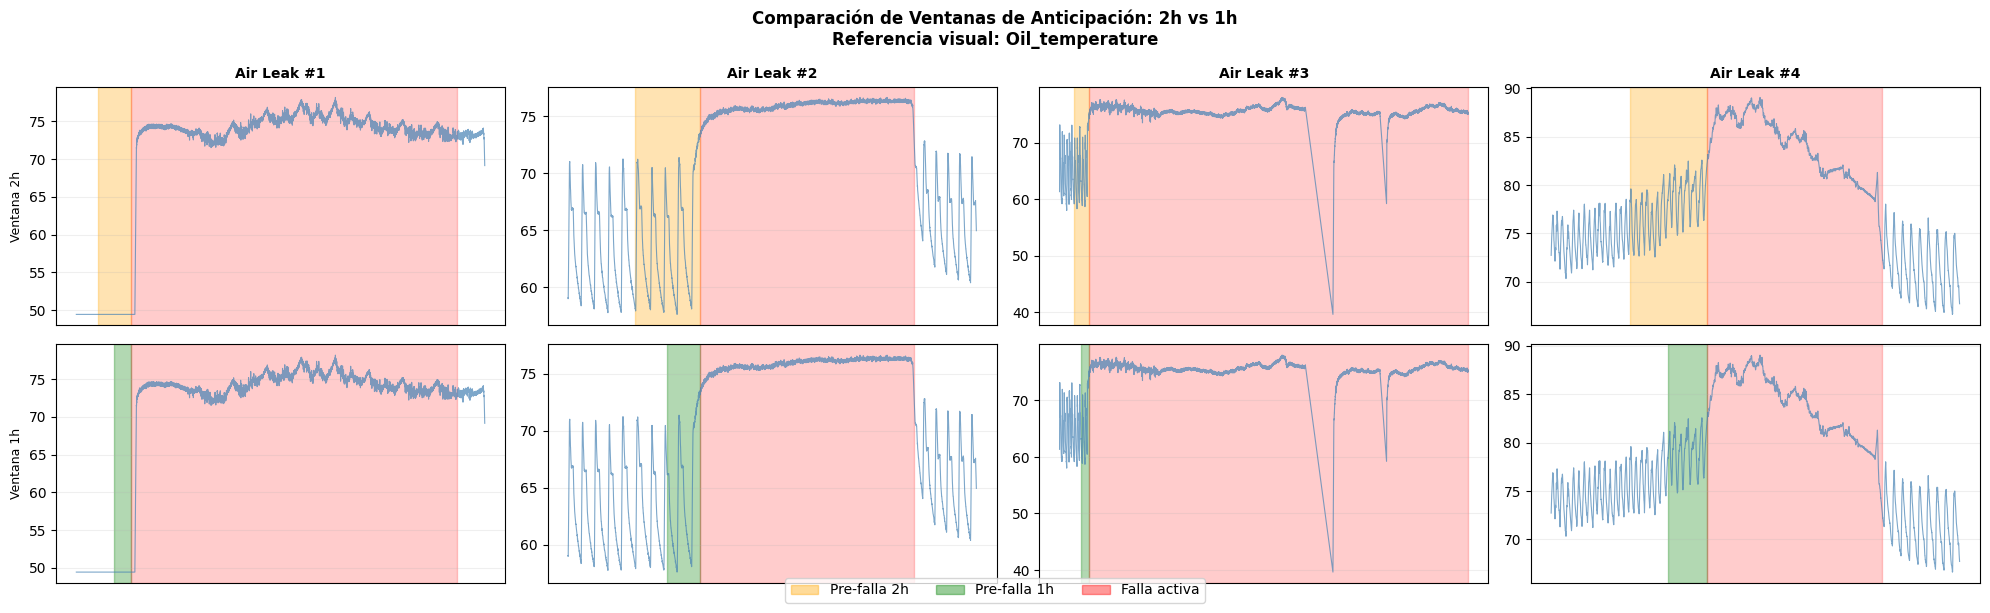

In [28]:
fallas_viz_ventana = [
    ('Air Leak #1', '2020-04-17 20:00:00', '2020-04-19 02:00:00'),
    ('Air Leak #2', '2020-05-29 19:30:00', '2020-05-30 08:00:00'),
    ('Air Leak #3', '2020-06-05 06:00:00', '2020-06-07 16:30:00'),
    ('Air Leak #4', '2020-07-15 10:30:00', '2020-07-15 21:00:00'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 6))

for col, (nombre, inicio, fin) in enumerate(fallas_viz_ventana):
    df_slice = df[
        (df['timestamp'] >= inicio) &
        (df['timestamp'] <= fin)
    ].copy()

    for row, (target, color, titulo) in enumerate([
        ('pre_failure',    'orange', 'Ventana 2h'),
        ('pre_failure_1h', 'green',  'Ventana 1h'),
    ]):
        ax = axes[row, col]

        # Señal del sensor más informativo como referencia
        ax.plot(df_slice['timestamp'], df_slice['Oil_temperature'],
                color='steelblue', linewidth=0.8, alpha=0.7, label='Oil_temperature')

        # Zona de pre-falla
        pre = df_slice[df_slice[target] == 1]['timestamp']
        if len(pre) > 0:
            ax.axvspan(pre.min(), pre.max(),
                       alpha=0.3, color=color, label=titulo)

        # Zona de falla
        fal = df_slice[df_slice['failure'] == 1]['timestamp']
        if len(fal) > 0:
            ax.axvspan(fal.min(), fal.max(),
                       alpha=0.2, color='red', label='Falla')

        if row == 0:
            ax.set_title(nombre, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(titulo, fontsize=9)

        ax.set_xticks([])
        ax.grid(alpha=0.2)

handles = [
    plt.Rectangle((0,0),1,1, color='orange', alpha=0.4, label='Pre-falla 2h'),
    plt.Rectangle((0,0),1,1, color='green',  alpha=0.4, label='Pre-falla 1h'),
    plt.Rectangle((0,0),1,1, color='red',    alpha=0.4, label='Falla activa'),
]
fig.legend(handles=handles, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Comparación de Ventanas de Anticipación: 2h vs 1h\n'
             'Referencia visual: Oil_temperature',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

 ## Configuración LOFO para ventana 1h

In [29]:
fallas_lofo_2h = fallas_lofo.copy()

fallas_lofo_1h = [
    {
        'nombre':            'Air Leak #1',
        'failure_inicio':    pd.Timestamp('2020-04-18 00:00:00'),
        'failure_fin':       pd.Timestamp('2020-04-18 23:59:00'),
        'prefailure_inicio': pd.Timestamp('2020-04-17 23:00:00'),
        'prefailure_fin':    pd.Timestamp('2020-04-17 23:59:50'),
    },
    {
        'nombre':            'Air Leak #2',
        'failure_inicio':    pd.Timestamp('2020-05-29 23:30:00'),
        'failure_fin':       pd.Timestamp('2020-05-30 06:00:00'),
        'prefailure_inicio': pd.Timestamp('2020-05-29 22:30:00'),
        'prefailure_fin':    pd.Timestamp('2020-05-29 23:29:50'),
    },
    {
        'nombre':            'Air Leak #3',
        'failure_inicio':    pd.Timestamp('2020-06-05 10:00:00'),
        'failure_fin':       pd.Timestamp('2020-06-07 14:30:00'),
        'prefailure_inicio': pd.Timestamp('2020-06-05 09:00:00'),
        'prefailure_fin':    pd.Timestamp('2020-06-05 09:59:50'),
    },
    {
        'nombre':            'Air Leak #4',
        'failure_inicio':    pd.Timestamp('2020-07-15 14:30:00'),
        'failure_fin':       pd.Timestamp('2020-07-15 19:00:00'),
        'prefailure_inicio': pd.Timestamp('2020-07-15 13:30:00'),
        'prefailure_fin':    pd.Timestamp('2020-07-15 14:29:50'),
    },
]

# Actualizamos la función para aceptar la lista como parámetro
def crear_folds_lofo(df, target, ratio=5, fallas=None):
    if fallas is None:
        fallas = fallas_lofo_2h

    sensores = ['TP3', 'H1', 'DV_pressure', 'Oil_temperature',
                'Motor_current', 'MPG', 'Towers']
    folds = []

    for falla in fallas:
        if target == 'failure':
            mascara_evento = (
                (df['timestamp'] >= falla['failure_inicio']) &
                (df['timestamp'] <= falla['failure_fin'])
            )
        else:
            mascara_evento = (
                (df['timestamp'] >= falla['prefailure_inicio']) &
                (df['timestamp'] <= falla['prefailure_fin'])
            )

        mascara_exclusion = (
            (df['timestamp'] >= falla['prefailure_inicio']) &
            (df['timestamp'] <= falla['failure_fin'])
        )

        test_pos = df[mascara_evento]
        test_neg = df[~mascara_evento & (df[target] == 0)].sample(
            n=min(len(test_pos) * ratio,
                  len(df[~mascara_evento & (df[target] == 0)])),
            random_state=42
        )
        test_df = pd.concat([test_pos, test_neg]).sort_index()

        train_df_full = df[~mascara_exclusion]
        train_pos = train_df_full[train_df_full[target] == 1]
        train_neg = train_df_full[train_df_full[target] == 0].sample(
            n=min(len(train_pos) * ratio,
                  len(train_df_full[train_df_full[target] == 0])),
            random_state=42
        )
        train_df = pd.concat([train_pos, train_neg]).sort_index()

        X_train = train_df[sensores]
        y_train = train_df[target]
        X_test  = test_df[sensores]
        y_test  = test_df[target]

        folds.append((X_train, X_test, y_train, y_test, falla['nombre']))

        print(f"  Fold {falla['nombre']}:")
        print(f"    Train → positivos: {y_train.sum()} | negativos: {(y_train==0).sum()}")
        print(f"    Test  → positivos: {y_test.sum()}  | negativos: {(y_test==0).sum()}")

    return folds

# Generamos los folds con ventana 1h
print("=== FOLDS LOFO — TARGET: pre_failure_1h ===")
folds_prefailure_1h = crear_folds_lofo(
    df,
    target='pre_failure_1h',
    fallas=fallas_lofo_1h
)

=== FOLDS LOFO — TARGET: pre_failure_1h ===
  Fold Air Leak #1:
    Train → positivos: 1142 | negativos: 5710
    Test  → positivos: 298  | negativos: 1490
  Fold Air Leak #2:
    Train → positivos: 1080 | negativos: 5400
    Test  → positivos: 359  | negativos: 1813
  Fold Air Leak #3:
    Train → positivos: 1080 | negativos: 5400
    Test  → positivos: 359  | negativos: 1813
  Fold Air Leak #4:
    Train → positivos: 1080 | negativos: 5400
    Test  → positivos: 359  | negativos: 1813


## Regresión Logística: pre_failure_1h

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline_lr_1h = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

res_lr_1h = entrenar_lofo(
    'Regresión Logística',
    pipeline_lr_1h,
    folds_prefailure_1h,
    'pre_failure_1h'
)
resultados.append(res_lr_1h)


Regresión Logística — target: pre_failure_1h

  Fold Air Leak #1:
    Precision: 0.000 | Recall: 0.000 | F1: 0.000

  Fold Air Leak #2:
    Precision: 0.221 | Recall: 0.482 | F1: 0.303

  Fold Air Leak #3:
    Precision: 0.219 | Recall: 0.496 | F1: 0.303

  Fold Air Leak #4:
    Precision: 0.000 | Recall: 0.000 | F1: 0.000

  ─────────────────────────────────────────────
  PROMEDIO LOFO:
    Precision: 0.110 ± 0.110
    Recall:    0.244 ± 0.244
    F1-Score:  0.152 ± 0.152


## Random Forest con pre_failure_1h


In [33]:
modelo_rf_1h = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

res_rf_1h = entrenar_lofo(
    'Random Forest',
    modelo_rf_1h,
    folds_prefailure_1h,
    'pre_failure_1h'
)
resultados.append(res_rf_1h)


Random Forest — target: pre_failure_1h

  Fold Air Leak #1:
    Precision: 0.723 | Recall: 1.000 | F1: 0.839

  Fold Air Leak #2:
    Precision: 0.634 | Recall: 0.284 | F1: 0.392

  Fold Air Leak #3:
    Precision: 0.604 | Recall: 0.259 | F1: 0.363

  Fold Air Leak #4:
    Precision: 0.000 | Recall: 0.000 | F1: 0.000

  ─────────────────────────────────────────────
  PROMEDIO LOFO:
    Precision: 0.490 ± 0.286
    Recall:    0.386 ± 0.372
    F1-Score:  0.399 ± 0.298


fsds

In [34]:
# Actualizamos crear_folds_lofo_eng para aceptar lista de fallas
def crear_folds_lofo_eng(df_eng, target, ratio=5, fallas=None):
    if fallas is None:
        fallas = fallas_lofo_2h

    folds = []
    for falla in fallas:
        if target == 'failure':
            mascara_evento = (
                (df_eng['timestamp'] >= falla['failure_inicio']) &
                (df_eng['timestamp'] <= falla['failure_fin'])
            )
        else:
            mascara_evento = (
                (df_eng['timestamp'] >= falla['prefailure_inicio']) &
                (df_eng['timestamp'] <= falla['prefailure_fin'])
            )

        mascara_exclusion = (
            (df_eng['timestamp'] >= falla['prefailure_inicio']) &
            (df_eng['timestamp'] <= falla['failure_fin'])
        )

        test_pos = df_eng[mascara_evento]
        test_neg = df_eng[~mascara_evento & (df_eng[target] == 0)].sample(
            n=min(len(test_pos) * ratio,
                  len(df_eng[~mascara_evento & (df_eng[target] == 0)])),
            random_state=42
        )
        test_df = pd.concat([test_pos, test_neg]).sort_index()

        train_df_full = df_eng[~mascara_exclusion]
        train_pos = train_df_full[train_df_full[target] == 1]
        train_neg = train_df_full[train_df_full[target] == 0].sample(
            n=min(len(train_pos) * ratio,
                  len(train_df_full[train_df_full[target] == 0])),
            random_state=42
        )
        train_df = pd.concat([train_pos, train_neg]).sort_index()

        X_train = train_df[features_xgb]
        y_train = train_df[target]
        X_test  = test_df[features_xgb]
        y_test  = test_df[target]

        folds.append((X_train, X_test, y_train, y_test, falla['nombre']))

        print(f"  Fold {falla['nombre']}:")
        print(f"    Train → positivos: {y_train.sum()} | negativos: {(y_train==0).sum()}")
        print(f"    Test  → positivos: {y_test.sum()}  | negativos: {(y_test==0).sum()}")

    return folds

In [36]:
df_eng['pre_failure_1h'] = df.loc[df_eng.index, 'pre_failure_1h']

print(f"Columnas de df_eng: {df_eng.columns.tolist()}")
print(f"pre_failure_1h en df_eng: {df_eng['pre_failure_1h'].sum()} registros positivos")

Columnas de df_eng: ['timestamp', 'TP3', 'H1', 'DV_pressure', 'Oil_temperature', 'Motor_current', 'Towers', 'MPG', 'failure', 'pre_failure', 'TP3_mean_30m', 'TP3_std_30m', 'H1_mean_30m', 'H1_std_30m', 'DV_pressure_mean_30m', 'DV_pressure_std_30m', 'Oil_temperature_mean_30m', 'Oil_temperature_std_30m', 'Motor_current_mean_30m', 'Motor_current_std_30m', 'pre_failure_1h']
pre_failure_1h en df_eng: 1440 registros positivos


In [37]:
print("=== FOLDS XGB — TARGET: pre_failure_1h ===")
folds_xgb_1h = crear_folds_lofo_eng(
    df_eng,
    target='pre_failure_1h',
    fallas=fallas_lofo_1h
)

modelo_xgb_1h = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42
)

res_xgb_1h = entrenar_lofo(
    'XGBoost',
    modelo_xgb_1h,
    folds_xgb_1h,
    'pre_failure_1h'
)
resultados.append(res_xgb_1h)

=== FOLDS XGB — TARGET: pre_failure_1h ===
  Fold Air Leak #1:
    Train → positivos: 1142 | negativos: 5710
    Test  → positivos: 298  | negativos: 1490
  Fold Air Leak #2:
    Train → positivos: 1080 | negativos: 5400
    Test  → positivos: 359  | negativos: 1813
  Fold Air Leak #3:
    Train → positivos: 1080 | negativos: 5400
    Test  → positivos: 359  | negativos: 1813
  Fold Air Leak #4:
    Train → positivos: 1080 | negativos: 5400
    Test  → positivos: 359  | negativos: 1813

XGBoost — target: pre_failure_1h

  Fold Air Leak #1:
    Precision: 0.971 | Recall: 1.000 | F1: 0.985

  Fold Air Leak #2:
    Precision: 0.929 | Recall: 0.217 | F1: 0.352

  Fold Air Leak #3:
    Precision: 0.963 | Recall: 0.145 | F1: 0.252

  Fold Air Leak #4:
    Precision: 0.000 | Recall: 0.000 | F1: 0.000

  ─────────────────────────────────────────────
  PROMEDIO LOFO:
    Precision: 0.716 ± 0.413
    Recall:    0.341 ± 0.389
    F1-Score:  0.397 ± 0.363


## Tabla Comparativa Final: Todos los modelos y targets.

In [38]:
import pandas as pd

df_resultados = pd.DataFrame(resultados)

# Formateamos para mejor lectura
df_resultados['Recall'] = df_resultados.apply(
    lambda r: f"{r['recall_mean']:.3f} ± {r['recall_std']:.3f}", axis=1
)
df_resultados['Precision'] = df_resultados.apply(
    lambda r: f"{r['precision_mean']:.3f} ± {r['precision_std']:.3f}", axis=1
)
df_resultados['F1'] = df_resultados.apply(
    lambda r: f"{r['f1_mean']:.3f} ± {r['f1_std']:.3f}", axis=1
)

tabla = df_resultados[['modelo', 'target', 'Precision', 'Recall', 'F1']]
tabla.columns = ['Modelo', 'Target', 'Precision', 'Recall', 'F1-Score']

print(tabla.to_string(index=False))

             Modelo         Target     Precision        Recall      F1-Score
Regresión Logística        failure 0.694 ± 0.367 0.711 ± 0.411 0.695 ± 0.397
Regresión Logística    pre_failure 0.087 ± 0.086 0.176 ± 0.174 0.116 ± 0.116
      Random Forest        failure 0.577 ± 0.382 0.287 ± 0.408 0.312 ± 0.395
      Random Forest    pre_failure 0.442 ± 0.256 0.437 ± 0.360 0.417 ± 0.273
            XGBoost        failure 0.737 ± 0.426 0.253 ± 0.427 0.258 ± 0.426
            XGBoost    pre_failure 0.587 ± 0.368 0.281 ± 0.417 0.303 ± 0.399
Regresión Logística pre_failure_1h 0.110 ± 0.110 0.244 ± 0.244 0.152 ± 0.152
      Random Forest pre_failure_1h 0.490 ± 0.286 0.386 ± 0.372 0.399 ± 0.298
            XGBoost pre_failure_1h 0.716 ± 0.413 0.341 ± 0.389 0.397 ± 0.363


## Conclusión Final del Notebook
---
* **Detección de falla activa (failure)**: La Regresión Logística fue el modelo con mejor desempeño general para esta tarea, alcanzando un recall promedio de 0.711 ± 0.411 y F1 de 0.695 ± 0.397, superando a Random Forest (Recall: 0.287) y XGBoost (Recall: 0.253). Este resultado contraintuitivo — donde el modelo más simple supera a los más complejos — sugiere que durante una falla activa los sensores exhiben patrones linealmente separables, y que los modelos de ensamble están sobreajustando a las características específicas de cada evento de entrenamiento.
 * **Anticipación de falla (pre_failure 2h y 1h)**: Ningún modelo logró un recall consistente para anticipar la falla antes de que ocurriera. El mejor resultado fue Random Forest con pre_failure (Recall: 0.437 ± 0.360) y pre_failure_1h (Recall: 0.386 ± 0.372), pero la alta desviación estándar en todos los casos revela que el rendimiento depende fuertemente del evento evaluado y no generaliza entre fallas. Reducir la ventana de anticipación de 2 horas a 1 hora no produjo mejoras significativas en ningún modelo, descartando la hipótesis de que la señal de degradación estaba diluida en la ventana más larga.
* **Limitación estructural del dataset**: El hallazgo más importante del análisis es que la falla #4 (Air Leak, 15 julio 2020) resultó indetectable para todos los modelos y todos los targets, con recall de 0.000 en todos los casos. El análisis visual de los sensores reveló que este evento se manifiesta como una degradación gradual sin una firma distinguible en los valores instantáneos, a diferencia de las fallas #1, #2 y #3 que producen cambios abruptos y claramente identificables. Con solo 4 eventos de falla disponibles, la exclusión efectiva de uno de ellos como indetectable reduce el conjunto de entrenamiento a 3 patrones, lo que es insuficiente para que cualquier modelo supervisado aprenda a generalizar.
* **Perspectivas**: Los resultados obtenidos motivan dos líneas de trabajo futuro. Primero, explorar modelos de detección de anomalías no supervisados — como Isolation Forest o Autoencoders — que no dependan de etiquetas de falla para aprender el comportamiento normal del sistema y detectar desviaciones, lo que podría capturar eventos como la falla #4 que no tienen una firma supervisada clara. Segundo, incorporar ventanas temporales más largas (1-4 horas) como features de entrada en lugar de como variable objetivo, permitiendo a los modelos capturar tendencias de degradación gradual que los valores instantáneos no revelan.